In [1]:
import struct
import math
import time
import csv

import casadi as ca
import numpy as np
from matplotlib import pyplot as plt

from scipy.spatial.transform import Rotation as R
from ahrs.common.orientation import acc2q
from ahrs import Quaternion

from scipy.signal import butter, filtfilt, lfilter, lfilter_zi

mincopter log: 50 entries with max 4044 records and min 4044
GPS lat: [-353632456, -353632617, -353632535, -353632534, -353632534]
GPS lng: [1491653270, 1491652518, 1491651531, 1491652370, 1491652247]
GPS alt: [484, 966, 0, 355, 726]
Home lat/lng: -353632619, 1491652369


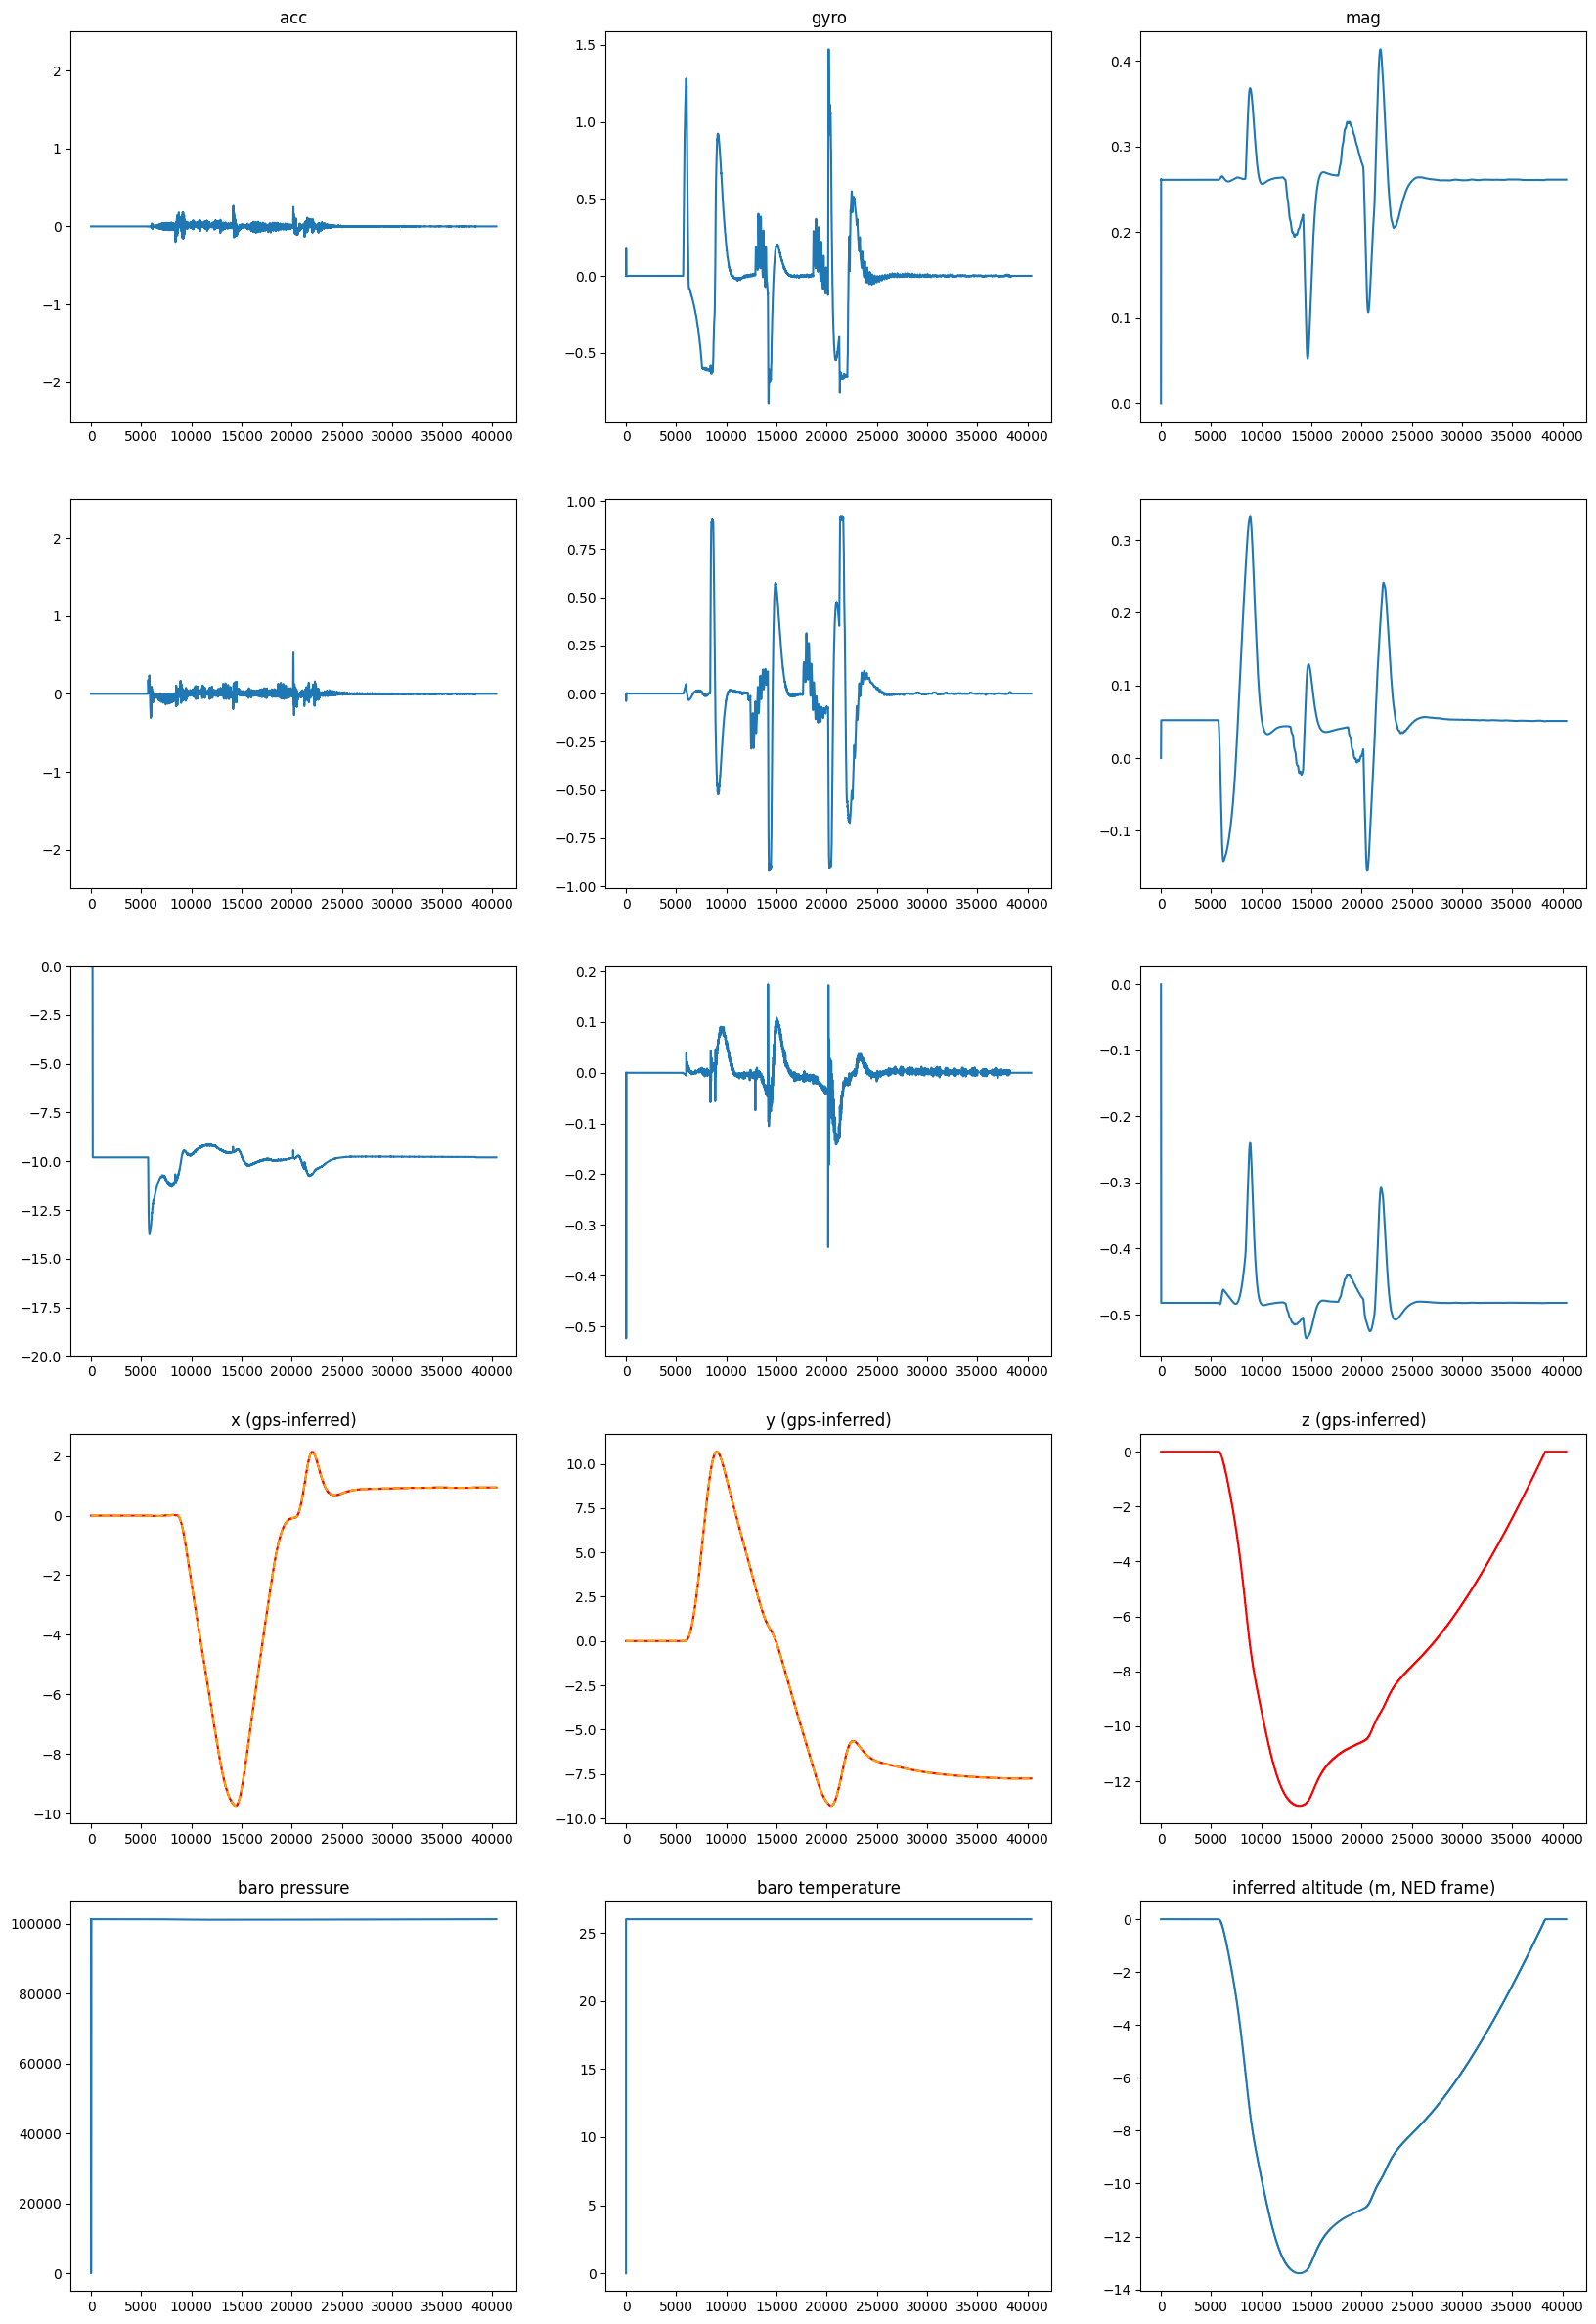

In [26]:
'''Read raw values'''
from parse import Parser
import mc_common
import random

parser = Parser()
mc_x, mc_y = parser.read_mincopter_log('../../build-generic/mincopter_log.txt')
gz_x, gz_y = parser.read_gz_log('/tmp/gz_imu_logfile.txt')

print(f'mincopter log: {len(mc_y.keys())} entries with max {max([len(mc_y[e]) for e in mc_y.keys()])} records \
and min {min([len(mc_y[e]) for e in mc_y.keys()])}')

print(f'GPS lat: {random.sample(mc_y['gps_lat'],5)}')
print(f'GPS lng: {random.sample(mc_y['gps_lng'],5)}')
print(f'GPS alt: {random.sample(mc_y['gps_alt_cm'],5)}')

fig, ax = plt.subplots(5,3, figsize=(20,30))

ax[0,0].set_title('acc')
ax[0,1].set_title('gyro')
ax[0,2].set_title('mag')

ax[0,0].plot(mc_x['accel_x'], mc_y['accel_x'])
ax[0,0].set_ylim(-2.5,2.5)
ax[1,0].plot(mc_x['accel_y'], mc_y['accel_y'])
ax[1,0].set_ylim(-2.5,2.5)
ax[2,0].plot(mc_x['accel_z'], mc_y['accel_z'])
ax[2,0].set_ylim(-20,0)

ax[0,1].plot(mc_x['gyro_x'], mc_y['gyro_x'])
ax[1,1].plot(mc_x['gyro_y'], mc_y['gyro_y'])
ax[2,1].plot(mc_x['gyro_z'], mc_y['gyro_z'])
ax[0,2].plot(mc_x['comp_x'], mc_y['comp_x'])
ax[1,2].plot(mc_x['comp_y'], mc_y['comp_y'])
ax[2,2].plot(mc_x['comp_z'], mc_y['comp_z'])

home_lat = None
home_lng = None
for e in mc_y['gps_lat']:
    if e != 0:
        home_lat = e
        break
for e in mc_y['gps_lng']:
    if e != 0:
        home_lng = e
        break

print(f'Home lat/lng: {home_lat}, {home_lng}')

gps_pos = [mc_common.gps_to_pos(mc_y['gps_lat'][i],
                                mc_y['gps_lng'][i],
                                mc_y['gps_alt_cm'][i], home_lat, home_lng, 0) for i in range(0, len(mc_y['gps_lat']))]

ax[3,0].plot(mc_x['gps_lat'], [g[0] for g in gps_pos], color='red')
ax[3,0].plot(mc_x['pos_x'], mc_y['pos_x'], color='orange', linestyle='--')
ax[3,0].set_title('x (gps-inferred)')

ax[3,1].plot(mc_x['gps_lng'], [g[1] for g in gps_pos], color='red')
ax[3,1].set_title('y (gps-inferred)')
ax[3,1].plot(mc_x['pos_y'], mc_y['pos_y'], color='orange', linestyle='--')

ax[3,2].plot(mc_x['gps_alt_cm'], [g[2] for g in gps_pos], color='red');
ax[3,2].set_title('z (gps-inferred)')

ground_pressure = None
ground_temperature = None
for e in mc_y['baro_pressure']:
    if e!=0.0:
        ground_pressure = e
        break
for e in mc_y['baro_temperature']:
    if e!=0.0:
        ground_temperature = e
        break

alt_inferred = [mc_common.baro_press_temp_to_alt(mc_y['baro_pressure'][i],
                                             mc_y['baro_temperature'][i],
                                                 ground_pressure,
                                                 ground_temperature) for i in range(0,len(mc_y['baro_pressure']))]

ax[4,0].plot(mc_x['baro_pressure'], mc_y['baro_pressure'])
ax[4,0].set_title('baro pressure')
ax[4,1].plot(mc_x['baro_temperature'], mc_y['baro_temperature'])
ax[4,1].set_title('baro temperature')
ax[4,2].plot(mc_x['baro_pressure'], alt_inferred)
ax[4,2].set_title('inferred altitude (m, NED frame)');

## Inferred Magnetometer Measurements
More complex than acc-inferred roll/pitch because it needs to be first corrected for roll/pitch

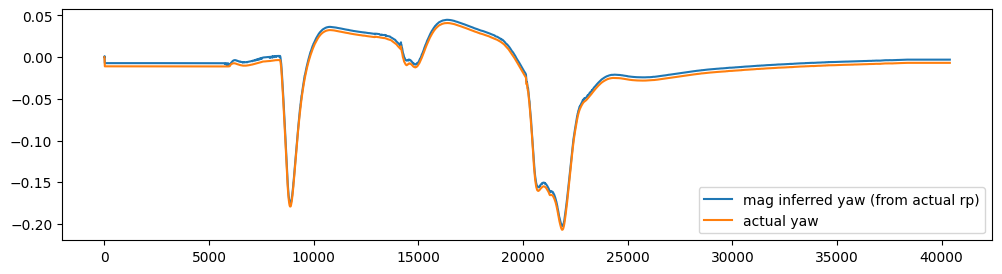

In [31]:
use_actuals = True

inferred_yaw = []

for i in range(0, len(mc_y['comp_x'])):
    if use_actuals:
        roll = mc_y['eul_x_a'][i]
        pitch = mc_y['eul_y_a'][i]
    else:
        roll = mc_y['roll'][i]
        pitch = mc_y['pitch'][i]

    m_norm = math.sqrt(mc_y['comp_x'][i]**2 + mc_y['comp_y'][i]**2 + mc_y['comp_z'][i]**2)

    if m_norm==0:
        inferred_yaw.append(0)
        continue
        
    mx_est = mc_y['comp_x'][i] / m_norm
    my_est = mc_y['comp_y'][i] / m_norm
    mz_est = mc_y['comp_z'][i] / m_norm    
    
    yaw_mag = math.atan2(-1*my_est*math.cos(roll) + mz_est*math.sin(roll),
                         mx_est*math.cos(pitch) + my_est*math.sin(pitch)*math.sin(roll) + mz_est*math.sin(pitch)*math.cos(roll))

    ## 3b. Add compass offset
    yaw_mag += 0.19
    
    inferred_yaw.append(yaw_mag)

fig, ax = plt.subplots(1,1, figsize=(12,3))
ax.plot(mc_x['comp_x'], inferred_yaw, label='mag inferred yaw (from actual rp)')
ax.plot(mc_x['comp_x'], mc_y['eul_z_a'], label='actual yaw')
ax.legend()


## Accelerometer Filtering (20Hz)

[0.0591907 0.0591907] [ 1.         -0.88161859]


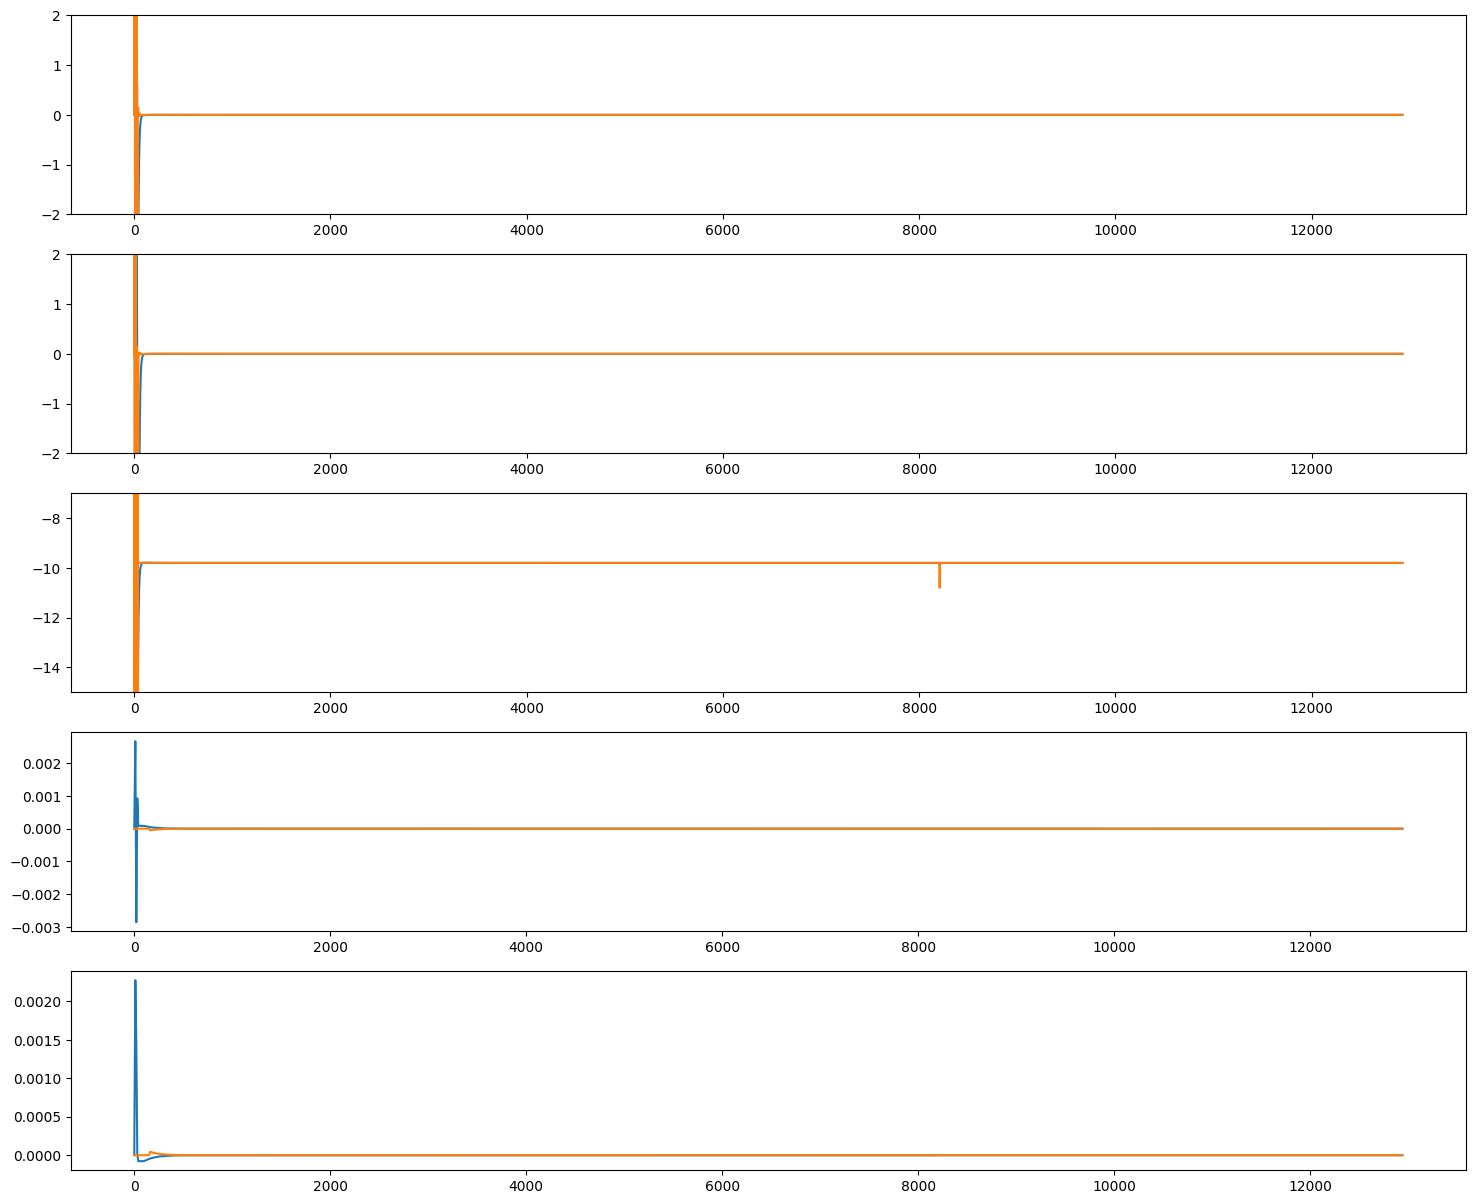

In [3]:
fs = 1000  # sampling frequency (Hz)
order = 1
cutoff = 20  # cutoff frequency (Hz)
normal_cutoff = cutoff / (fs / 2)  # normalized cutoff
b, a = butter(order, normal_cutoff, btype='low', analog=False)

print(b,a)
'''
zf = lfilter_zi(b, a) * 0
new_acc_x = []
for i in range(0,len(gz_y['ax'])):
    y, zf = lfilter(b,a, [gz_y['ax'][i]], zi=zf)
    new_acc_x.append(y)
'''

ax_filtered = lfilter(b, a, gz_y['ax'])
ay_filtered = lfilter(b, a, gz_y['ay'])
az_filtered = lfilter(b, a, gz_y['az'])

fig, ax = plt.subplots(5,1,figsize=(18,15))
rmin = 0
rmax = -1
ax[0].plot(gz_x['ax'][rmin:rmax], ax_filtered[rmin:rmax])
ax[0].plot(gz_x['ax'][rmin:rmax], gz_y['ax'][rmin:rmax])
ax[0].set_ylim(-2,2)
ax[1].plot(gz_x['ay'][rmin:rmax], ay_filtered[rmin:rmax])
ax[1].plot(gz_x['ay'][rmin:rmax], gz_y['ay'][rmin:rmax])
ax[1].set_ylim(-2,2)
ax[2].plot(gz_x['az'][rmin:rmax], az_filtered[rmin:rmax])
ax[2].plot(gz_x['az'][rmin:rmax], gz_y['az'][rmin:rmax])
ax[2].set_ylim(-15,-7)

ax[3].plot(mc_x['roll'], mc_y['roll'])
ax[4].plot(mc_x['pitch'], mc_y['pitch'])

roll_inferred_gz = [math.atan2(-mc_y['accel_y'][i], -mc_y['accel_z'][i]) for i in range(0,len(mc_y['accel_x']))]
ax[3].plot(mc_x['roll'], roll_inferred_gz)

pitch_inferred_gz = [math.atan2(mc_y['accel_x'][i], math.sqrt(mc_y['accel_y'][i]**2+mc_y['accel_z'][i]**2)) for i in range(0,len(mc_y['accel_x']))]
ax[4].plot(mc_x['pitch'], pitch_inferred_gz)


We can try and re-create the expected accelerometer reading using the derivative of the (actual) velocity and the (actual) attitude.
$$\begin{align}\begin{bmatrix}a_{x} \\ a_{y} \\ a_{z}\end{bmatrix} &=
\begin{bmatrix} a_{x,body} \\ a_{y,body} \\ a_{z,body}
\end{bmatrix} + \mathbf{g}_{body} \\ &= R^{T}a_{inertial} + R^{T}g_{inertial} \end{align}
$$

## Gyrometer Filtering (2Hz)

[0.00624404 0.00624404] [ 1.         -0.98751193]


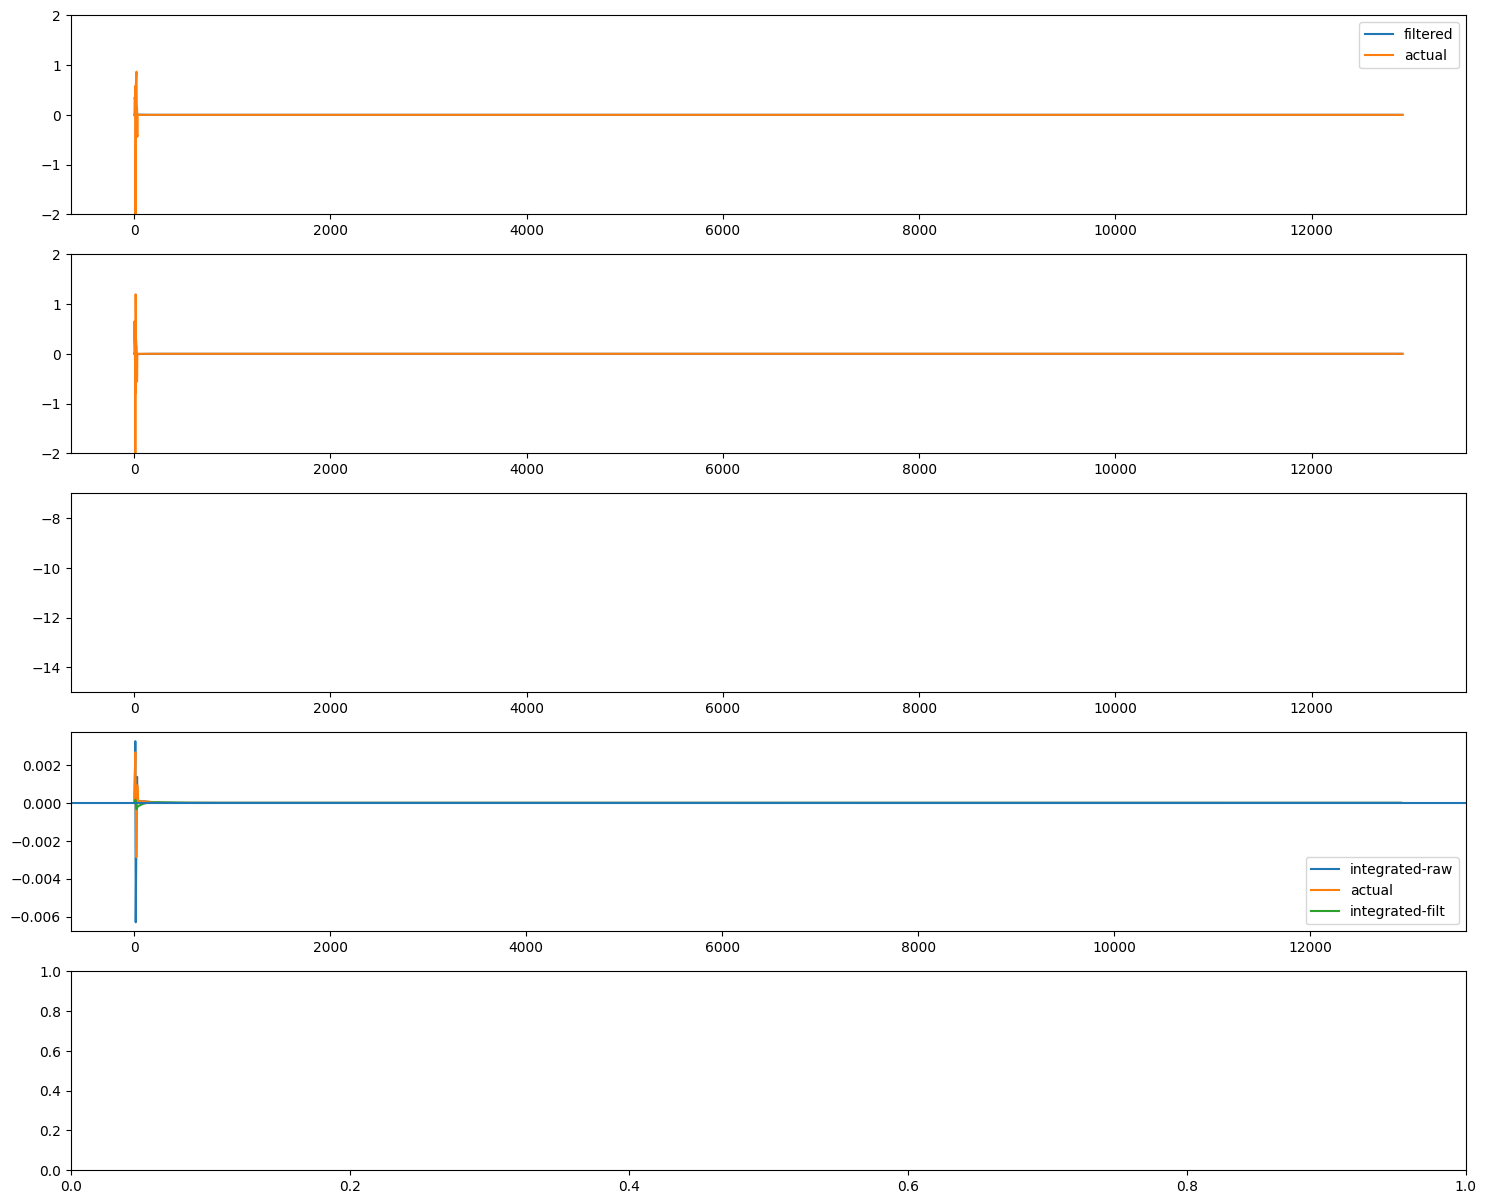

In [4]:
fs = 1000  # sampling frequency (Hz)
order = 1
cutoff = 2  # cutoff frequency (Hz)
normal_cutoff = cutoff / (fs / 2)  # normalized cutoff
b, a = butter(order, normal_cutoff, btype='low', analog=False)

print(b,a)
'''
zf = lfilter_zi(b, a) * 0
new_acc_x = []
for i in range(0,len(gz_y['ax'])):
    y, zf = lfilter(b,a, [gz_y['ax'][i]], zi=zf)
    new_acc_x.append(y)
'''

ax_filtered = lfilter(b, a, gz_y['gx'])
ay_filtered = lfilter(b, a, gz_y['gy'])
az_filtered = lfilter(b, a, gz_y['gz'])

fig, ax = plt.subplots(5,1,figsize=(18,15))
rmin = 0
rmax = -1
ax[0].plot(gz_x['ax'][rmin:rmax], ax_filtered[rmin:rmax], label='filtered')
ax[0].plot(gz_x['ax'][rmin:rmax], gz_y['gx'][rmin:rmax], label='actual')
ax[0].legend()
ax[0].set_ylim(-2,2)
ax[1].plot(gz_x['ay'][rmin:rmax], ay_filtered[rmin:rmax])
ax[1].plot(gz_x['ay'][rmin:rmax], gz_y['gy'][rmin:rmax])
ax[1].set_ylim(-2,2)
ax[2].plot(gz_x['az'][rmin:rmax], az_filtered[rmin:rmax])
ax[2].plot(gz_x['az'][rmin:rmax], gz_y['gz'][rmin:rmax])
ax[2].set_ylim(-15,-7)

roll_integrated_raw = []
roll_integrated_filt = []
for i,e in enumerate(gz_y['gx']):
    roll_integrated_raw.append(roll_integrated_raw[i-1] + 0.001*e if i!=0 else 0)

for i,e in enumerate(ax_filtered):
    roll_integrated_filt.append(roll_integrated_filt[i-1] + 0.001*e if i!=0 else 0)


ax[3].plot(roll_integrated_raw, label='integrated-raw')
ax[3].plot(mc_x['roll'], mc_y['roll'], label='actual')
ax[3].plot(roll_integrated_filt, label='integrated-filt')
ax[3].axhline(y=0)
ax[3].legend()

In [5]:
## Temporary roll,pitch,yaw
troll=0
tpitch=0
tyaw=0

lowest_mse_div = 1e9
lowest_fuse_pc = 1e9
lowest_mse = 1e9

iterations = min(len(mc_y['roll'])*10, max(gz_x['ax']))

for div_max in np.linspace(0,5,100):
    for fuse_pc in np.linspace(0,0.1,20):

        mse = 0
        for i in range(0,iterations,10):
            ## Retrieve every 10th reading (100Hz)
        
            pitch_acc = math.atan2(gz_y['ax'][i], math.sqrt(gz_y['ay'][i]**2 + gz_y['az'][i]**2))
            roll_acc = math.atan2(-gz_y['ay'][i], -gz_y['az'][i])
        
            ## Integrate gyro
            roll_gyr = troll + 0.01*gz_y['gx'][i]
            pitch_gyr = tpitch + 0.01*gz_y['gy'][i]
                        
            ## Fuse with a weight based on how much we are accelerating
            a_norm = math.sqrt(gz_y['ax'][i]**2 + gz_y['ay'][i]**2 + gz_y['az'][i]**2)
                    
            div = abs(a_norm-9.8)
            if div>div_max:
                ## Ignore accel reading altogether
                a = 1
            else:
                ## Accel reading should by up to 2% of the fused value when we are stationary
                a = 1 - (div_max-div)*fuse_pc/div_max
            
            troll = a*roll_gyr + (1-a)*roll_acc
            tpitch = a*pitch_gyr + (1-a)*pitch_acc

            mse += (troll-mc_y['roll'][i//10])**2

        if mse<lowest_mse:
            lowest_mse = mse
            lowest_mse_div = div_max
            lowest_fuse_pc = fuse_pc

print(lowest_mse, lowest_fuse_pc, lowest_mse_div)


/tmp/ipykernel_964502/3594539668.py:35: RuntimeWarning: invalid value encountered in scalar divide
  a = 1 - (div_max-div)*fuse_pc/div_max


1000000000.0 1000000000.0 1000000000.0


[ 1.         -1.56101808  0.64135154]
[0.02008337 0.04016673 0.02008337]


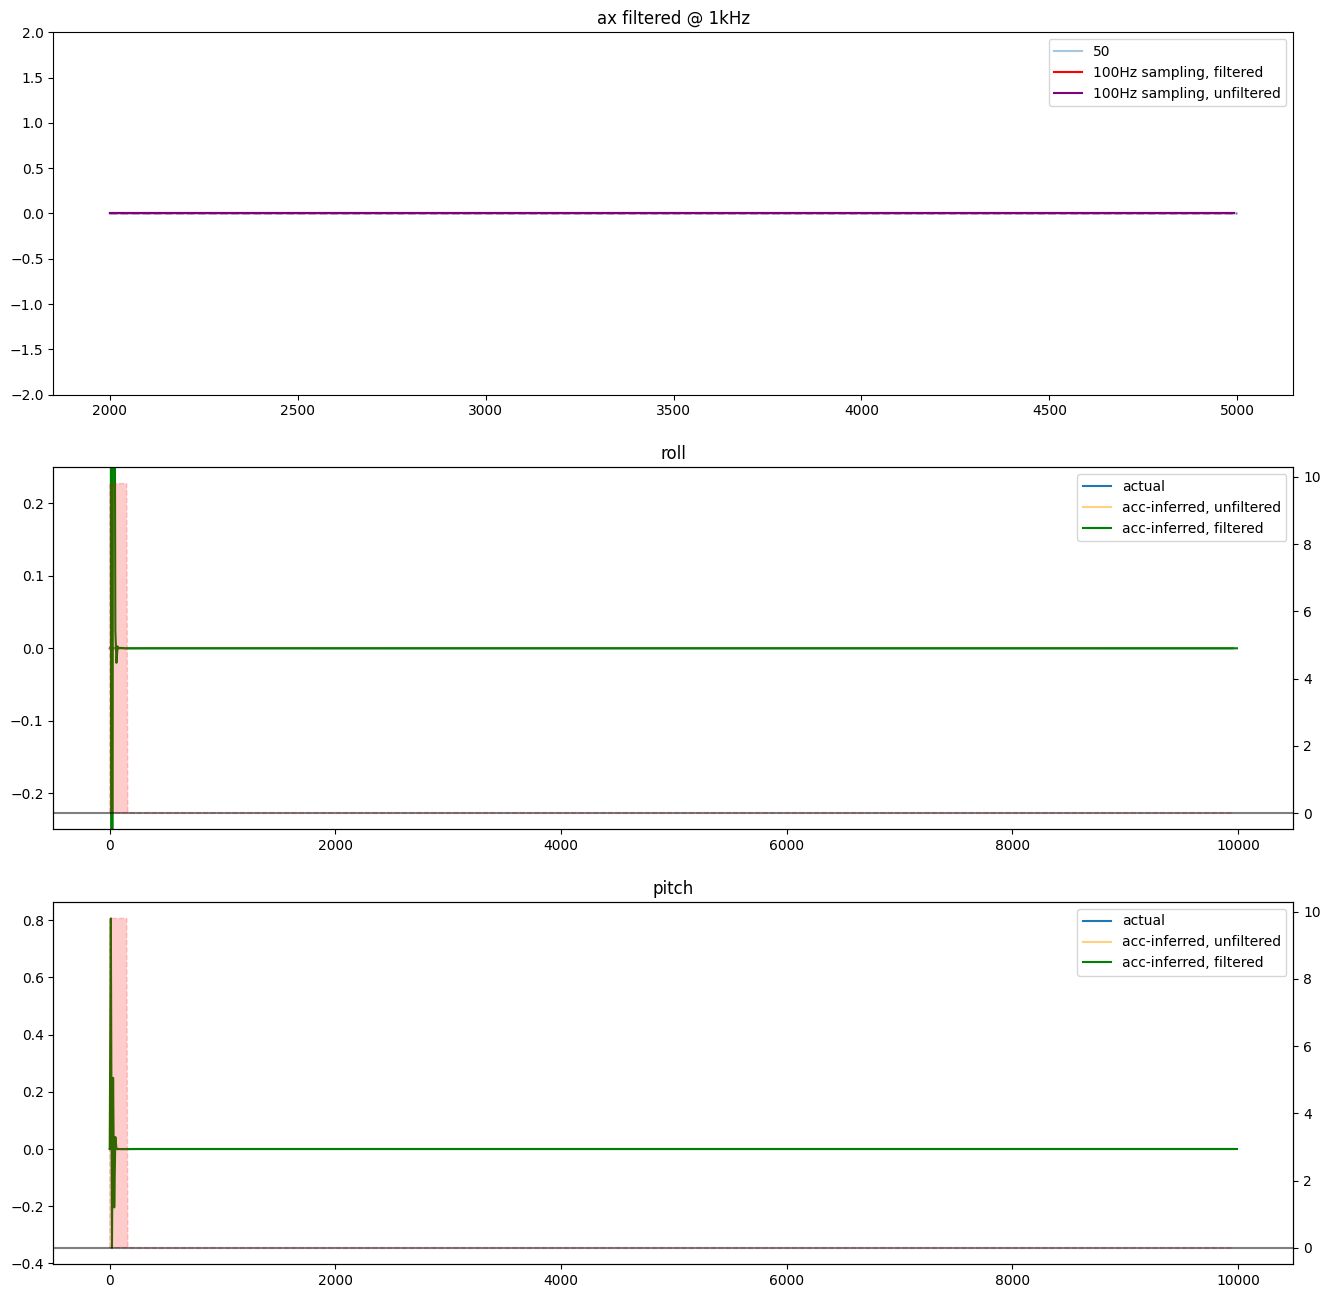

In [6]:
'''Filter design'''
fs = 1000  # sampling frequency (Hz)
order = 2
cutoff = 50  # cutoff frequency (Hz)
normal_cutoff = cutoff / (fs / 2)  # normalized cutoff
b, a = butter(order, normal_cutoff, btype='low', analog=False)

'''
zf = lfilter_zi(b, a) * 0
new_acc_x = []
for i in range(0,len(gz_y['ax'])):
    y, zf = lfilter(b,a, [gz_y['ax'][i]], zi=zf)
    new_acc_x.append(y)
'''

ax_filtered = lfilter(b, a, gz_y['ax'])
ay_filtered = lfilter(b, a, gz_y['ay'])
az_filtered = lfilter(b, a, gz_y['az'])

x_range = range(0,len(ax_filtered))
rmin=2000
rmax=5000

fig, ax = plt.subplots(3,1, figsize=(16, 16))
ax[0].plot(x_range[rmin:rmax], ax_filtered[rmin:rmax], label=cutoff, alpha=0.4)
ax[0].plot(x_range[rmin:rmax], gz_y['ax'][rmin:rmax], color='black', linestyle='--', alpha=0.4)
ax[0].plot(x_range[rmin:rmax:10], ax_filtered[rmin:rmax:10], label='100Hz sampling, filtered', color='red')
ax[0].plot(x_range[rmin:rmax:10], gz_y['ax'][rmin:rmax:10], label='100Hz sampling, unfiltered', color='purple')

ax[0].legend()
ax[0].set_title('ax filtered @ 1kHz')
ax[0].set_ylim(-2,2)

## Plot the actual roll,pitch and compare with accelerometer-inferred roll/pitch
anorm = [abs(9.8-math.sqrt(mc_y['accel_x'][i]**2 + mc_y['accel_y'][i]**2+mc_y['accel_z'][i]**2)) for i in range(0,len(mc_y['accel_x']))]

roll_inferred = [math.atan2(-mc_y['accel_y'][i], -mc_y['accel_z'][i]) for i in range(0,len(mc_y['accel_x']))]
filtered_roll_inferred = [math.atan2(-ay_filtered[i], -az_filtered[i]) for i in range(0,len(gz_y['ax']),10)]

pitch_inferred = [math.atan2(mc_y['accel_x'][i], math.sqrt(mc_y['accel_y'][i]**2+mc_y['accel_z'][i]**2)) for i in range(0,len(mc_y['accel_x']))]
filtered_pitch_inferred = [math.atan2(ax_filtered[i], math.sqrt(ay_filtered[i]**2+az_filtered[i]**2)) for i in range(0,len(gz_y['ax']),10)]

rmax=1000
ax[1].plot(mc_x['roll'][:rmax], mc_y['roll'][:rmax], label='actual')
ax[1].plot(mc_x['accel_x'][:rmax], roll_inferred[:rmax], label='acc-inferred, unfiltered', alpha=0.5, color='orange')
ax[1].plot(list(range(0,len(gz_y['ax']),10))[:rmax], filtered_roll_inferred[:rmax], label='acc-inferred, filtered', color='green')
ax2 = ax[1].twinx()
ax2.fill_between(mc_x['roll'][:rmax], anorm[:rmax], color='red', alpha=0.2, label='Accel norm deviation from 9.8', linestyle='--')
ax2.axhline(y=0, color='black', alpha=0.5)
ax[1].set_title('roll')
ax[1].set_ylim(-0.25, 0.25)
ax[1].legend()

ax[2].plot(mc_x['pitch'][:rmax], mc_y['pitch'][:rmax], label='actual')
ax[2].plot(mc_x['accel_x'][:rmax], pitch_inferred[:rmax], label='acc-inferred, unfiltered', alpha=0.5, color='orange')
ax[2].plot(list(range(0,len(gz_y['ax']),10))[:rmax], filtered_pitch_inferred[:rmax], label='acc-inferred, filtered', color='green')
ax2 = ax[2].twinx()
ax2.fill_between(mc_x['pitch'][:rmax], anorm[:rmax], color='red', alpha=0.2, label='Accel norm deviation from 9.8', linestyle='--')
ax2.axhline(y=0, color='black', alpha=0.5)
ax[2].legend()
ax[2].set_title('pitch')

#pitch_acc = math.atan2(y_av['ax'][i], math.sqrt(y_av['ay'][i]**2 + y_av['az'][i]**2))
#roll_acc = math.atan2(-y_av['ay'][i], -y_av['az'][i])

print(a)
print(b)
a_frac = np.array([ 1.0, -3.18063855, 3.86119435, -2.11215536, 0.43826514])
b_frac = np.array([0.0004166, 0.0016664, 0.0024996, 0.0016664, 0.0004166])

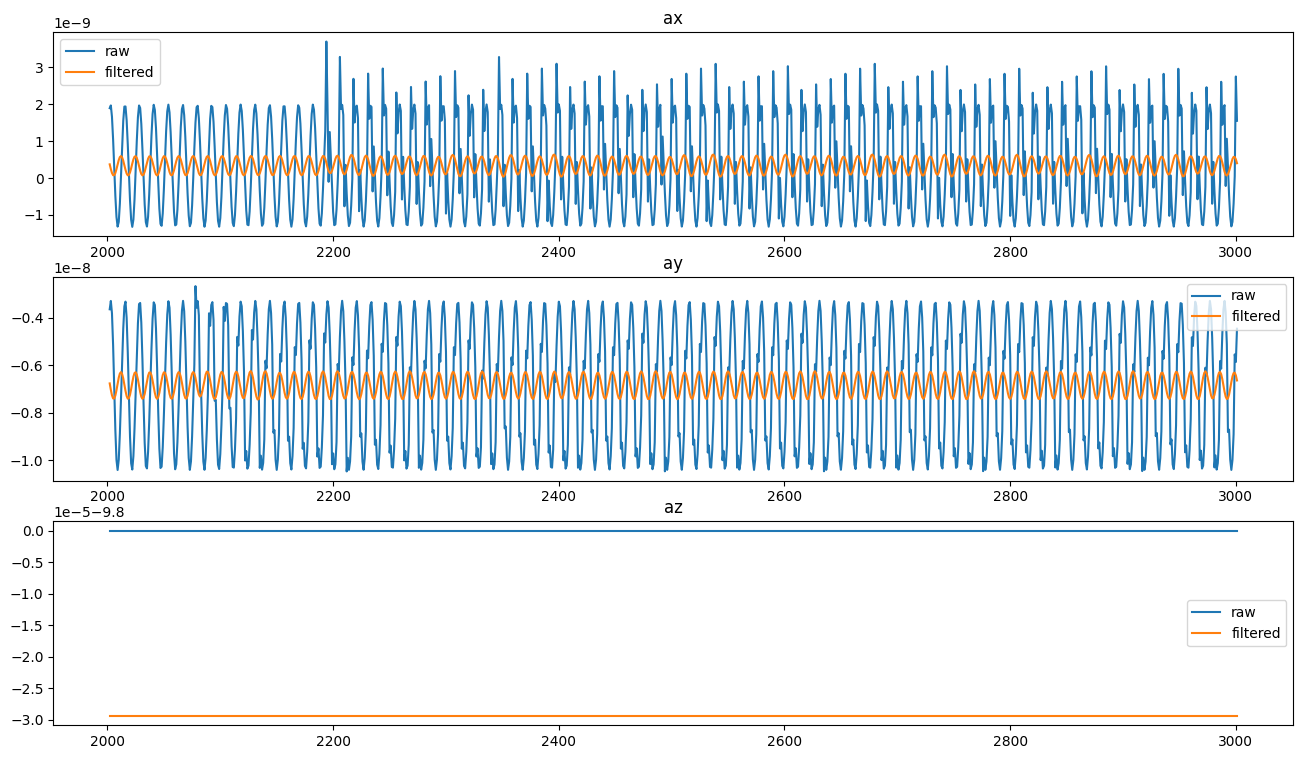

In [7]:
'''Filtering of accelerometer data filtered values available in ax_filt, ay_filt, az_filt @1kHz'''

## Initialise accel filter
acc_filt_a = np.array([ 1.0, -3.18063855, 3.86119435, -2.11215536, 0.43826514])
acc_filt_b = np.array([0.0004166, 0.0016664, 0.0024996, 0.0016664, 0.0004166])
zf_x = lfilter_zi(acc_filt_b, acc_filt_a) * 0
zf_y = lfilter_zi(acc_filt_b, acc_filt_a) * 0
zf_z = lfilter_zi(acc_filt_b, acc_filt_a) * 0
    
ax_filt = []
ay_filt = []
az_filt = []
for i in range(0,len(gz_y['ax'])):
    acc_x_filt, zf_x = lfilter(acc_filt_b, acc_filt_a, [gz_y['ax'][i]], zi=zf_x)
    acc_y_filt, zf_y = lfilter(acc_filt_b, acc_filt_a, [gz_y['ay'][i]], zi=zf_y)
    acc_z_filt, zf_z = lfilter(acc_filt_b, acc_filt_a, [gz_y['az'][i]], zi=zf_z)
    ax_filt.append(acc_x_filt)
    ay_filt.append(acc_y_filt)
    az_filt.append(acc_z_filt)
    #ax_av.append(sum(gz_y['ax'][max(0,i-10):i])/10)

fig, ax = plt.subplots(3,1, figsize=(16,9))
rmin=2000
rmax=3000
for i, a, f in zip([0,1,2], ['ax','ay','az'], [ax_filt, ay_filt, az_filt]):
    ax[i].plot(gz_x[a][rmin:rmax], gz_y[a][rmin:rmax], label='raw')
    ax[i].plot(gz_x[a][rmin:rmax], f[rmin:rmax], label='filtered')
    ax[i].set_title(a)
    #ax[i].set_ylim(-2,2)
    ax[i].legend()
